In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
plt.rcParams['font.sans-serif'] = ['SimHei']

In [2]:
#获取数据
df = pd.read_json('../douban_top250.json', convert_dates=False)

In [3]:
#处理数据

df['rank'] = pd.to_numeric(df['rank'], errors='coerce')
df['rating_num'] = pd.to_numeric(df['rating_num'], errors='coerce')
df['rating_people'] = pd.to_numeric(df['rating_people'], errors='coerce')

df['date'] = pd.to_datetime(df['date'], errors='coerce').dt.year
df['date'] = df['date'].astype('Int64')

df['attrs'] = df['attrs'].str.replace("/...",'')
df['attrs'] = df['attrs'].str.replace("/ ...",'')
df['attrs'] = df['attrs'].str.replace("...",'')
df['attrs'] = df['attrs'].str.replace(":",'')

df.fillna(np.nan, inplace=True)

df.to_csv("douban_top250_analysis.csv", index=False)
df.to_json("douban_top250_analysis.json", orient='records',force_ascii=False,indent=2)

In [4]:
#数据分析
rating_num = df['rating_num'].values
mean = np.mean(rating_num)
std = np.std(rating_num)
median = np.median(rating_num)
min = np.min(rating_num)
max = np.max(rating_num)

date = df['date'].value_counts().sort_index()

rating_bins = pd.cut(df['rating_num'],bins=[8,8.5,9,9.5,10],labels=['8-8.5','8.5-9','9-9.5','9.5-10'])
rating_bins_count = rating_bins.value_counts().sort_values()

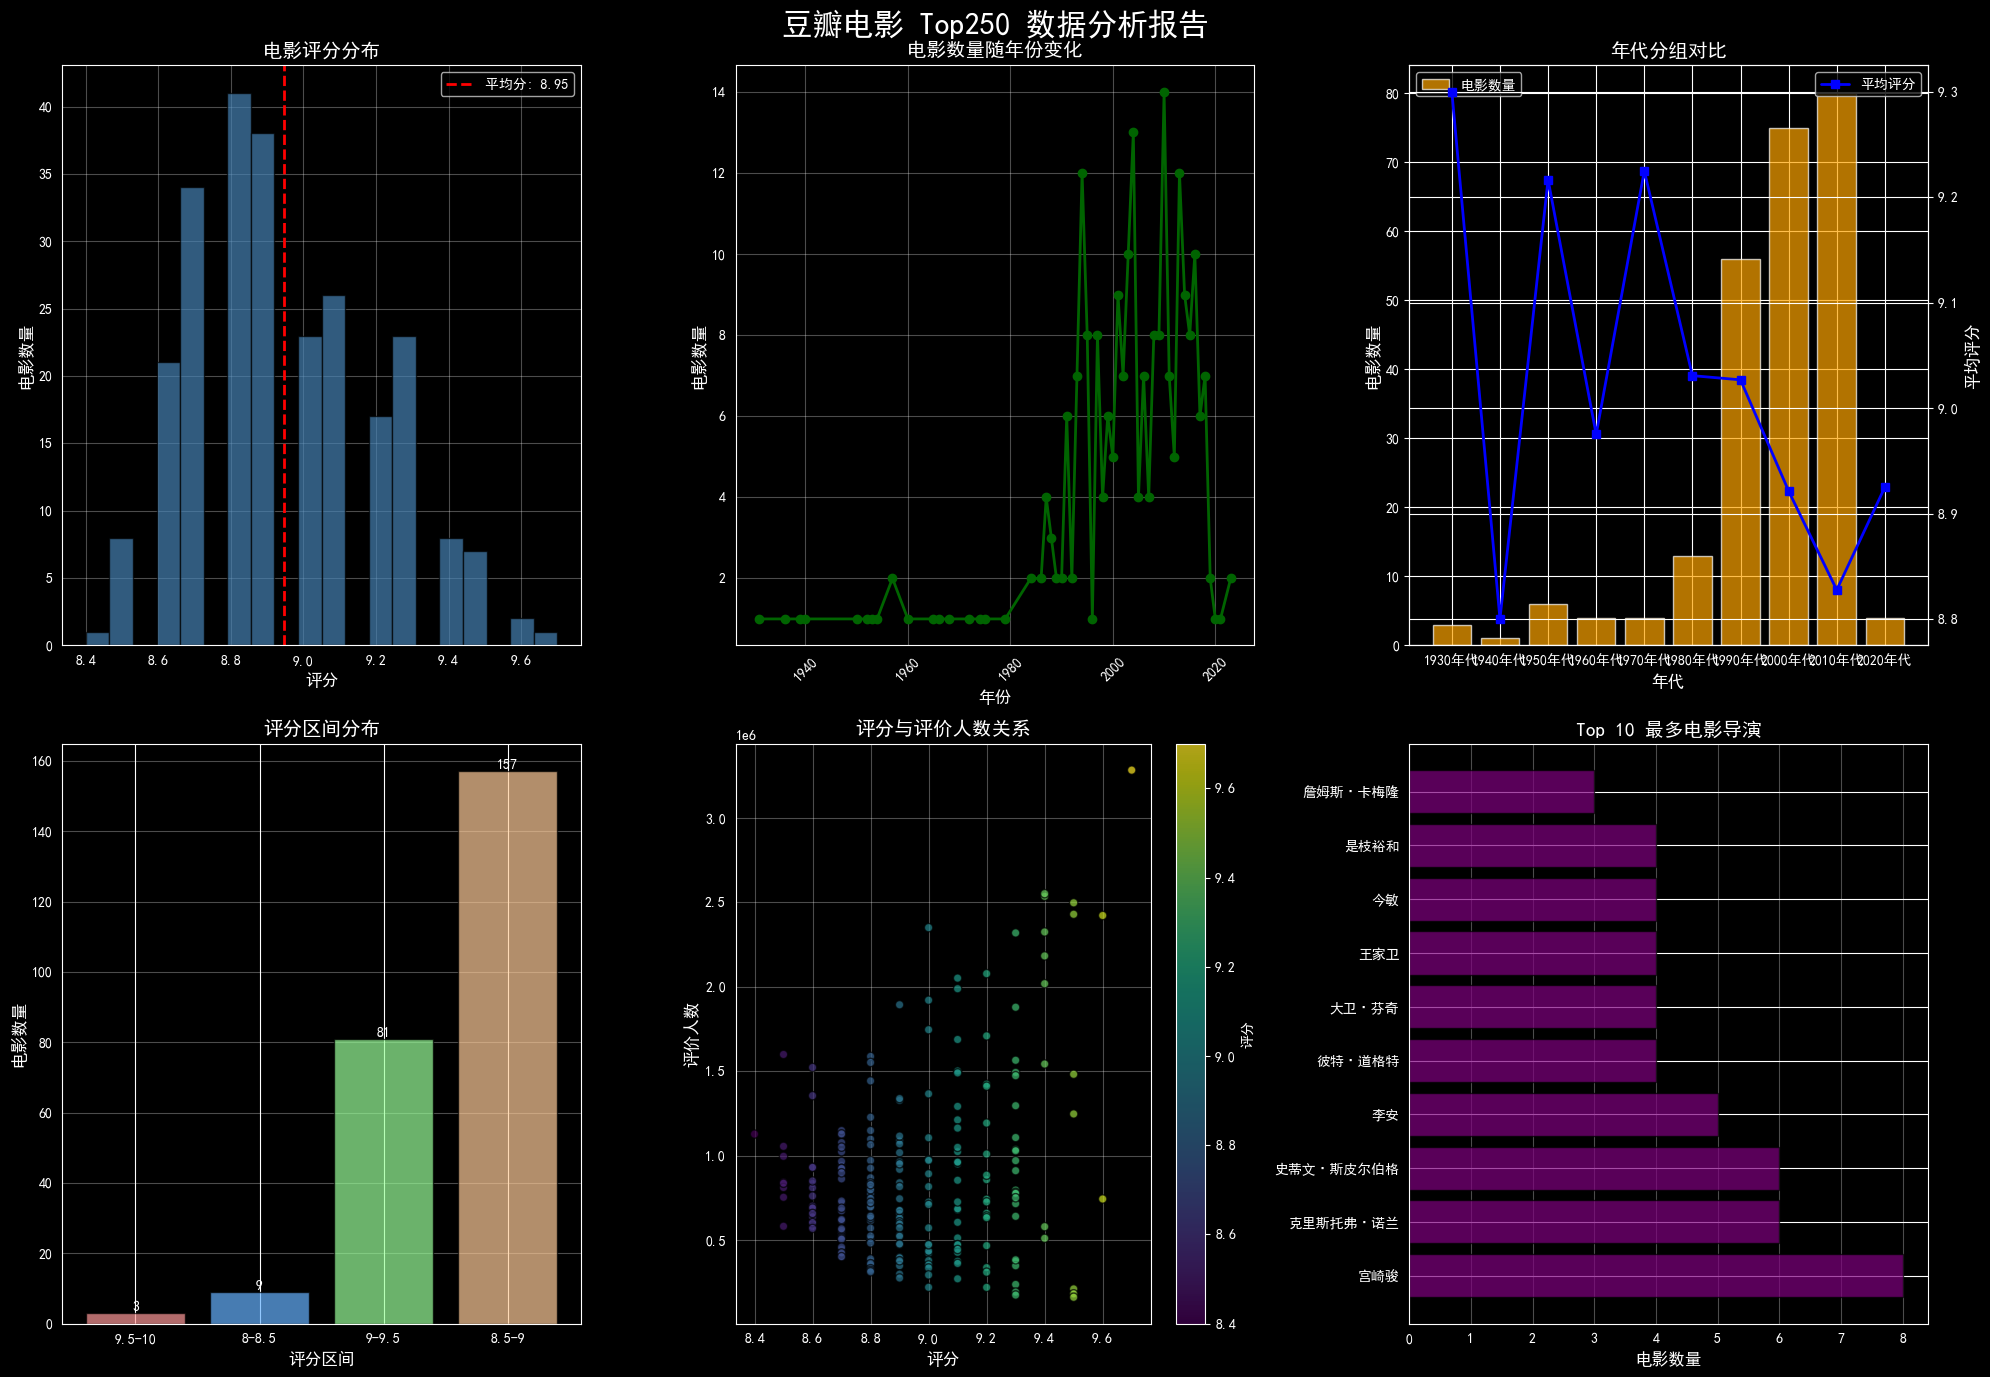

In [5]:
#数据可视化
fig = plt.figure(figsize=(20, 14))
plt.suptitle('豆瓣电影 Top250 数据分析报告', fontsize=22, fontweight='bold')

#1.评分分布直方图
ax1 = plt.subplot(2, 3, 1)
plt.hist(df['rating_num'], bins=20, color='steelblue', alpha=0.7, edgecolor='black')
plt.title('电影评分分布', fontsize=14, fontweight='bold')
plt.xlabel('评分', fontsize=12)
plt.ylabel('电影数量', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'平均分: {mean:.2f}')
plt.legend()

#2.电影数量随年份变化
ax2 = plt.subplot(2, 3, 2)
plt.plot(date.index, date.values, marker='o', linewidth=2, color='darkgreen')
plt.title('电影数量随年份变化', fontsize=14, fontweight='bold')
plt.xlabel('年份', fontsize=12)
plt.ylabel('电影数量', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

#3.年代分组对比图
ax3 = plt.subplot(2, 3, 3)
df['decade'] = (df['date'] // 10) * 10
decade_stats = df.groupby('decade')['rating_num'].agg(['mean', 'count'])
decade_stats = decade_stats.dropna()
ax3.bar(decade_stats.index.astype(str) + '年代', decade_stats['count'], color='orange', alpha=0.7, label='电影数量')
ax3_twin = ax3.twinx()
ax3_twin.plot(decade_stats.index.astype(str) + '年代', decade_stats['mean'], marker='s', color='blue', linewidth=2, label='平均评分')
ax3.set_title('年代分组对比', fontsize=14, fontweight='bold')
ax3.set_xlabel('年代', fontsize=12)
ax3.set_ylabel('电影数量', fontsize=12)
ax3_twin.set_ylabel('平均评分', fontsize=12)
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')
plt.xticks(rotation=45)

#4.不同评分区间的电影数量
ax4 = plt.subplot(2, 3, 4)
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
bars = plt.bar(rating_bins_count.index, rating_bins_count.values, color=colors, edgecolor='black', alpha=0.7)
plt.title('评分区间分布', fontsize=14, fontweight='bold')
plt.xlabel('评分区间', fontsize=12)
plt.ylabel('电影数量', fontsize=12)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}',
             ha='center', va='bottom', fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

#5.评分和评价人数散点图
ax5 = plt.subplot(2, 3, 5)
plt.scatter(df['rating_num'], df['rating_people'], c=df['rating_num'], cmap='viridis', alpha=0.7, edgecolor='black')
plt.colorbar(label='评分')
plt.title('评分与评价人数关系', fontsize=14, fontweight='bold')
plt.xlabel('评分', fontsize=12)
plt.ylabel('评价人数', fontsize=12)
plt.grid(True, alpha=0.3)

#6.导演出现次数统计
ax6 = plt.subplot(2, 3, 6)
directors = df['director'].apply(lambda x: str(x).split()[0] if pd.notna(x) else '')
director_counts = Counter(directors)
top_directors = dict(director_counts.most_common(10))
plt.barh(list(top_directors.keys()), list(top_directors.values()), color='purple', alpha=0.7, edgecolor='black')
plt.xlabel('电影数量', fontsize=12)
plt.title('Top 10 最多电影导演', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

plt.tight_layout()

plt.savefig('douban_top250_analysis.png', dpi=300, bbox_inches='tight')

plt.show()